In [1]:
import re
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from venny4py.venny4py import *
from Bio import SeqIO, Entrez
import py3Dmol

from dotenv import load_dotenv
env_file = '/home/yuan/bio/bio_omics/src/.env'
load_dotenv(dotenv_path = env_file)

%load_ext autoreload
%autoreload 2

In [2]:
src_dir = os.path.dirname(os.getcwd())
print('src direcotry is ', src_dir)
bioomics_dir = '/home/yuan/bio/bio_omics/src'
for _dir in (src_dir, bioomics_dir):
    if _dir not in sys.path:
        sys.path.append(_dir)
print(sys.path)

from bioomics import QueryComplex
from plot_venn import PlotVenn
from plot_region import PlotRegion
from layout import Layout

src direcotry is  /home/yuan/bio/predict_antibody
['/home/yuan/bio/anaconda3/envs/simulate2/lib/python312.zip', '/home/yuan/bio/anaconda3/envs/simulate2/lib/python3.12', '/home/yuan/bio/anaconda3/envs/simulate2/lib/python3.12/lib-dynload', '', '/home/yuan/bio/anaconda3/envs/simulate2/lib/python3.12/site-packages', '/home/yuan/bio/predict_antibody', '/home/yuan/bio/bio_omics/src']


In [3]:
query = "select * from view_antibody;"
adf = QueryComplex(True).list_data(query, True)

INFO:mysql.connector:package: mysql.connector.plugins
INFO:mysql.connector:plugin_name: caching_sha2_password
INFO:mysql.connector:AUTHENTICATION_PLUGIN_CLASS: MySQLCachingSHA2PasswordAuthPlugin


In [7]:
query = """
 select * from align_jregion where isotype='IG' and identities = align_len
;"""
df = QueryComplex(True).list_data(query, True)
print(df.shape)
df = df[df['chain_id'].isin(adf['chain_id'])]
print(df.shape)
df.head(2)

(145257, 20)
(116785, 20)


,pdb_id,chain_id,query_len,allele_name,specie,gene_name,gene_family,chain_type,isotype,evalue,bit_score,match_seq,identities,align_len,query_seq,query_start,query_end,sbjct_seq,sbjct_start,sbjct_end
0,3IJH,3IJH_0_A_0,217,IGKJ2*01,Mus_musculus,IGKJ2,None,K,IG,0.004198,27,TFGGGTKLEIK,11,11,TFGGGTKLEIK,101,111,TFGGGTKLEIK,2,12
1,3IJH,3IJH_0_A_0,217,IGKJ1*01,Mus_musculus,IGKJ1,None,K,IG,0.005621,26,TFGGGTKLEIK,11,11,TFGGGTKLEIK,101,111,TFGGGTKLEIK,2,12


figure size: 8.5 x 6 cm


Text(0, 0.5, 'Percentage, %')

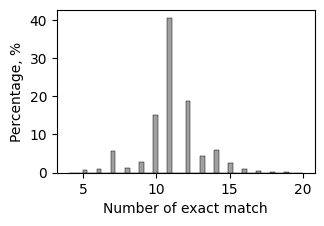

In [76]:
# length of J-region
args = {'width_level': 1, 'height': 6}
fig, ax = Layout(args).one()

sns.histplot(df, x='identities', ax=ax, bins=50, stat='percent', color='grey')
ax.set_xlabel('Number of exact match')
ax.set_ylabel('Percentage, %')

In [8]:
chain_type = 'H'
sub = df[df['chain_type']==chain_type]
counts = df.groupby(['allele_name', 'identities']).agg({'chain_id': 'nunique'})
counts = counts.rename(columns={'chain_id':'counts'})
counts = counts.sort_values('counts', ascending=False).reset_index()
counts.head()

,allele_name,identities,counts
0,IGKJ2*01,11,2733
1,IGKJ1*01,11,2184
2,IGKJ4*01,11,2143
3,IGKJ1*02,10,1775
4,IGHJ4*01,7,1608


figure size: 17.4 x 8 cm
H: chains= 9593	pdb= 5001
K: chains= 9207	pdb= 5125
L: chains= 2864	pdb= 1495


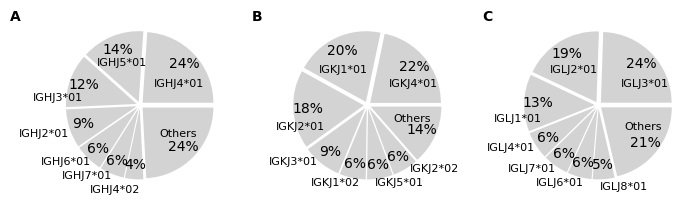

In [77]:
args = {'width_level': 3, 'height': 8, 'space':.1}
label_x = (-30, -20, -20)
label_y = 5
fig, axes = Layout(args).row(label_x, label_y)

c = PlotRegion(df)
params = {'chain_type': 'H', 'n': 7, 'explode': [.05,]*8, 'pctdistance':.8, 'labeldistance':1,
    'text_pos':[(.9,.3), (.1,.6), (-.8,.1), (-1,-.4), (-.7,-.8), (-.4,-1),(0,-1.2),(.8,-.4),]}
c.pie_jregion(axes[0], params)
params = {'chain_type': 'K', 'n': 7, 'explode': [.05,]*8, 'pctdistance':.8, 'labeldistance':1,
    'text_pos':[(1,.3), (0,.5), (-.6,-.3), (-.7,-.8), (-.1,-1.1), (.8,-1.1),(1.3,-.9),(.9,-.2),]}
c.pie_jregion(axes[1], params)
params = {'chain_type': 'L', 'n': 7, 'explode': [.05,]*8, 'pctdistance':.8, 'labeldistance':1,
    'text_pos':[(1,.3), (0,.5), (-.8,-.2), (-.9,-.6), (-.6,-.9), (-.2,-1.1),(.7,-1.15),(.9,-.3),]}
c.pie_jregion(axes[2], params)

fig.savefig('../figures/count_J-region.tif', dpi=300, bbox_inches='tight', pad_inches=.05)